# QUA — Câu hỏi 1: Sự khác biệt giữa **mdx** (mô hình DMD) và **WT**

**Study 22-082 · muscle Quadriceps (QUA) · deep-dive trên toàn bộ QUA fibers (n ≈ 111k)**

## Mục tiêu
Xác định *chữ ký bệnh học* (pathological signature) của cơ dystrophic (mdx) so với chứng khỏe mạnh (WT),
trên từng fiber và trong từng morphological cluster, dùng dữ liệu multiplex fiber-to-fiber đã matched.

## Thiết kế phân tích & nguyên tắc reproducibility
- **Clustering không dùng lại (no re-clustering).** Ta nạp *precomputed* UMAP cache
  `results/QUA/clustering_cache/ch3_zscore_pca30_mindist0.0_nn15.npz` — đây là embedding
  **ch3 preset = 15 morphology features + HE (slide 6)**, tức là *unbiased* với mọi
  immunostaining. PCA/UMAP (phần ngẫu nhiên, tốn kém) **không** chạy lại; chỉ tái lập lại
  bước gán nhãn **GMM k=6 (deterministic, `random_state=42`)** đúng như `scripts/plot_umap.py`.
  Kết quả cluster ổn định tuyệt đối giữa các lần chạy.
- **6 clusters (Cls1–Cls6)** được diễn giải sinh học bên dưới. Khung của nhóm nghiên cứu:
  *Cls2/3/4/6 = treatment-responsive*, *Cls5 = treatment-resistant* (dùng ở Notebook 2).
- **Thống kê ở mức con vật (per-animal).** Fiber là pseudo-replicate; test giả thuyết dùng
  **median mỗi con vật** rồi so nhóm bằng **Mann–Whitney U** + **Cohen's d** (n = 5 WT / 5 mdx / 4 AAV9 / 5 LICA1).
  Với n=5 vs 5, p nhỏ nhất có thể của MWU = 0.008 (tách hoàn toàn).
- **Chỉ dùng giá trị OBSERVED** (fiber thực sự matched trên slide đó); NaN **không** impute khi tính thống kê marker.
- **Hướng NADH/COX** (brightfield) được xác định *thực nghiệm*: NADH↑ tương quan dương với Myh7/Myh2
  (type I/IIa oxidative) và âm với Myh4 (IIb) → ở dataset này **giá trị cao = oxidative cao**.

### 1 · Thiết lập (self-contained, reproducible)

In [1]:
# === Self-contained, reproducible setup (no /DATA symlink, no external bundle) ===
# Reproduces the analysis matrix from the repo's PRECOMPUTED UMAP cache.
# Clustering (PCA+UMAP) is NOT re-run: we load the cached embedding and reproduce
# only the deterministic GMM labelling (random_state=42), exactly as the repo's
# plot_umap.py does. This guarantees the same 6 clusters every run.
import os, sys, pickle, warnings, hashlib
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")

# ---- locate repo root (works from scripts/, notebooks/, or repo root) ----
def find_repo_root():
    for base in [Path.cwd()] + list(Path.cwd().parents):
        if (base / "config" / "ddc_config.py").exists() and (base / "results" / "QUA").exists():
            return base
    for cand in [Path("/home/user/F2FMatcher_DDC"), Path("/DATA/F2FMatcher_DDC")]:
        if (cand / "config" / "ddc_config.py").exists():
            return cand
    raise RuntimeError("Cannot locate F2FMatcher_DDC repo root")
REPO = find_repo_root()
sys.path.insert(0, str(REPO))
from config.ddc_config import (SLIDES, MASK_FEATURES, QUA_SAMPLES, GROUP_MAP,
                               get_group, FEATURE_STATISTICS, ANALYSIS_CONFIG)

MUSCLE = "QUA"
RES = REPO / "results" / MUSCLE
COMBINED = RES / "features_combined"
CACHE = RES / "clustering_cache" / "ch3_zscore_pca30_mindist0.0_nn15.npz"
COMPARTMENT_ORDER = ["whole", "mem", "cyto1", "cyto2"]
RANDOM_STATE = ANALYSIS_CONFIG["random_state"]   # 42
GROUPS = ["WT", "mdx", "AAV9", "LICA1"]
GCOL = {"WT": "#0000C0", "mdx": "#FF6000", "AAV9": "#C0C000", "LICA1": "#008000"}
CLUSTER_COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00", "#a65628"]
CLUSTERS = [1, 2, 3, 4, 5, 6]
K = 6

def feature_columns():
    """807-col combined vector layout: 15 mask + 36 per channel (22 channels)."""
    cols = list(MASK_FEATURES)
    for slide in SLIDES:
        for ch, stain in SLIDES[slide]["stainings"].items():
            for comp in COMPARTMENT_ORDER:
                for stat in FEATURE_STATISTICS:
                    cols.append(f"S{slide}_{stain}_{comp}_{stat}")
    return cols

def slide_channel_blocks():
    blocks, off = {}, 0
    for slide in SLIDES:
        n = len(SLIDES[slide]["stainings"]); blocks[slide] = (off, n); off += n
    return blocks

def load_all_full():
    """Full 807-feature matrix for all QUA fibers (row order == cluster cache order)."""
    frames = []
    for s in QUA_SAMPLES:
        with open(COMBINED / f"{s}.pkl", "rb") as f:
            d = pickle.load(f)
        for lid, vec in d.items():
            frames.append(list(vec) + [lid, s, get_group(s)])
    cols = feature_columns() + ["label_id", "sample", "group"]
    return pd.DataFrame(frames, columns=cols)

def build_analysis_frame(verbose=True):
    """Load precomputed UMAP cache, reproduce GMM(k=6) labels, align full features.
    Cached to results/QUA/clustering_cache/analysis_frame_ch3_k6.npz for fast re-runs."""
    from sklearn.mixture import GaussianMixture
    fast = CACHE.parent / "analysis_frame_ch3_k6.npz"
    z = np.load(CACHE, allow_pickle=True)
    Xpca = z["X_pca"]; Xumap = z["X_umap"]
    groups = z["groups"].astype(str); samples = z["samples"].astype(str)
    # deterministic GMM labelling on the cached PCA embedding (same as plot_umap.py)
    labels = GaussianMixture(n_components=K, covariance_type="full", n_init=1,
                             max_iter=200, random_state=RANDOM_STATE).fit_predict(Xpca) + 1
    if fast.exists():
        c = np.load(fast, allow_pickle=True)
        if np.array_equal(c["samples"].astype(str), samples) and np.array_equal(c["labels"], labels):
            if verbose: print(f"Loaded aligned analysis frame from {fast.name}")
            return dict(Xpre=c["Xpre"], Xumap=Xumap, groups=groups, samples=samples,
                        labels=labels, cols=[str(x) for x in c["cols"]])
    df = load_all_full()
    full_cols = feature_columns()
    Xfull = df[full_cols].to_numpy(np.float64)
    blocks = slide_channel_blocks()
    # ch3 detection filter: fiber detected on slide 6 (HE) — reproduces the cache's rows
    st, nc = blocks[6]
    detected = (~np.isnan(Xfull[:, 15 + st*36:15 + (st+nc)*36])).any(axis=1)
    keep = detected >= 1
    Xpre = Xfull[keep]
    assert np.array_equal(df["sample"].to_numpy()[keep], samples), "row alignment mismatch"
    np.savez_compressed(fast, Xpre=Xpre, cols=np.array(full_cols),
                        samples=samples, labels=labels)
    if verbose: print(f"Built & cached aligned analysis frame -> {fast.name}")
    return dict(Xpre=Xpre, Xumap=Xumap, groups=groups, samples=samples,
                labels=labels, cols=full_cols)


In [2]:
# === Analysis helpers: marker panel, per-fiber values, per-animal statistics ===
import numpy as np, pandas as pd
from scipy import stats

# marker -> (column or [RGB cols], short biological meaning)
MARKERS = {
    "area":            ("area", "fiber cross-sectional area (size)"),
    "roundness":       ("roundness", "circularity"),
    "eccentricity":    ("eccentricity", "elongation"),
    "solidity":        ("solidity", "convexity"),
    "minor_axis":      ("minor_axis_length", "min Feret diameter"),
    "Dystrophin_mem":  ("S1_Dystrophin_mem_mean", "sarcolemmal dystrophin"),
    "Laminin_mem":     ("S1_Laminin_mem_mean", "basal-lamina laminin"),
    "Collagen4_mem":   ("S1_Collagen4_mem_mean", "peri-fiber collagen-IV / fibrosis"),
    "DAPI_cyto2":      ("S1_DAPI_cyto2_mean", "central nucleation (regeneration)"),
    "DAPI_mem":        ("S1_DAPI_mem_mean", "peripheral (normal) nuclei"),
    "IgG_whole":       ("S2_IgG_whole_mean", "IgG influx (necrosis / leaky sarcolemma)"),
    "CD11b_mem":       ("S2_CD11b_mem_mean", "CD11b+ myeloid infiltration"),
    "NADH":            (["S3_R_whole_mean","S3_G_whole_mean","S3_B_whole_mean"], "NADH-TR (oxidative; ↑=more oxidative here)"),
    "COX":             (["S7_R_whole_mean","S7_G_whole_mean","S7_B_whole_mean"], "COX (oxidative; ↑=more oxidative here)"),
    "Myh7":            ("S4_Myh7_whole_mean", "MyHC-I (slow oxidative)"),
    "Myh2":            ("S4_Myh2_whole_mean", "MyHC-IIa"),
    "Myh4":            ("S4_Myh4_whole_mean", "MyHC-IIb (fast glycolytic)"),
    "LAMP2":           ("S8_LAMP2_whole_mean", "LAMP2 (lysosomal membrane)"),
    "LGALS3":          ("S8_LGALS3_whole_mean", "galectin-3 (lysosomal damage)"),
    "SQSTM1":          ("S8_SQSTM1_whole_mean", "p62/SQSTM1 (autophagy)"),
    "HE_hematox_B":    ("S6_B_whole_mean", "HE hematoxylin (basophilia)"),
    "HE_eosin_R":      ("S6_R_whole_mean", "HE eosin"),
}
SLIDE8 = {"LAMP2", "LGALS3", "SQSTM1"}   # AAV9 mapping unreliable (15.7%) -> excluded

class QUA:
    """Bundles the analysis frame + marker accessors and per-animal statistics."""
    def __init__(self, D):
        self.Xpre = D["Xpre"]; self.Xumap = D["Xumap"]
        self.groups = D["groups"]; self.samples = D["samples"]; self.labels = D["labels"]
        self.cols = D["cols"]; self.cidx = {c: i for i, c in enumerate(self.cols)}
        self.usamp = np.unique(self.samples)
        self.sgroup = {s: self.groups[self.samples == s][0] for s in self.usamp}

    def mval(self, name):
        spec = MARKERS[name][0]
        if isinstance(spec, str):
            return self.Xpre[:, self.cidx[spec]]
        return np.nanmean(np.stack([self.Xpre[:, self.cidx[c]] for c in spec]), axis=0)

    def valid_groups(self, name):
        return [g for g in GROUPS if not (name in SLIDE8 and g == "AAV9")]

    def per_animal(self, name, cluster=None, stat="median"):
        """Per-animal summary (median by default) of observed marker; optional within-cluster."""
        v = self.mval(name); ok = ~np.isnan(v)
        if cluster is not None: ok = ok & (self.labels == cluster)
        rows = []
        for s in self.usamp:
            m = ok & (self.samples == s)
            if m.sum() >= 10:
                val = np.median(v[m]) if stat == "median" else np.mean(v[m])
                rows.append((s, self.sgroup[s], val, int(m.sum())))
        return pd.DataFrame(rows, columns=["sample", "group", "val", "n"])

    def cluster_fraction(self):
        rows = []
        for s in self.usamp:
            m = self.samples == s
            r = {"sample": s, "group": self.sgroup[s]}
            for c in CLUSTERS: r[f"Cls{c}"] = (self.labels[m] == c).mean() * 100
            rows.append(r)
        return pd.DataFrame(rows)

def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

def mwu(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2: return np.nan
    try: return stats.mannwhitneyu(a, b, alternative="two-sided").pvalue
    except ValueError: return np.nan

def spearman_masked(a, b, nmin=50):
    m = ~np.isnan(a) & ~np.isnan(b)
    if m.sum() < nmin: return np.nan, int(m.sum())
    return stats.spearmanr(a[m], b[m]).correlation, int(m.sum())

def stars(p):
    if p is None or np.isnan(p): return "n/a"
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


In [3]:
# === Figure functions (shared by both notebooks) ===
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

def _strip_by_group(ax, df, groups_use, title, ylab, ref=None):
    """per-animal points + group mean bars."""
    for i, g in enumerate(groups_use):
        vals = df[df.group == g]["val"].values
        ax.bar(i, np.mean(vals), color=GCOL[g], alpha=0.35, width=0.6, zorder=1)
        ax.scatter(np.full(len(vals), i) + np.random.RandomState(0).uniform(-.12, .12, len(vals)),
                   vals, color=GCOL[g], edgecolor="k", lw=.5, s=34, zorder=3)
        ax.hlines(np.mean(vals), i-.3, i+.3, color="k", lw=1.6, zorder=4)
    if ref is not None:
        ax.axhline(ref, ls="--", lw=1, color="#0000C0", alpha=.6, zorder=0)
    ax.set_xticks(range(len(groups_use))); ax.set_xticklabels(groups_use)
    ax.set_title(title, fontsize=10.5, fontweight="bold"); ax.set_ylabel(ylab)

# ---------- Q1 figures ----------
def fig_umap_reference(q, out):
    fig, ax = plt.subplots(1, 2, figsize=(12, 5.2))
    rs = np.random.RandomState(1); order = rs.permutation(len(q.labels))
    for g in GROUPS:
        m = q.groups[order] == g
        ax[0].scatter(q.Xumap[order][m, 0], q.Xumap[order][m, 1], s=3, alpha=.25,
                      color=GCOL[g], edgecolors="none")
    ax[0].legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=GCOL[g],
                 markersize=8,label=g) for g in GROUPS], loc="best", fontsize=9)
    ax[0].set_title("UMAP (morphology + HE), by group", fontweight="bold")
    for c in CLUSTERS:
        m = q.labels[order] == c
        ax[1].scatter(q.Xumap[order][m, 0], q.Xumap[order][m, 1], s=3, alpha=.25,
                      color=CLUSTER_COLORS[c-1], edgecolors="none")
        cx, cy = q.Xumap[q.labels==c].mean(0)
        ax[1].text(cx, cy, str(c), fontsize=15, fontweight="bold", ha="center", va="center",
                   bbox=dict(boxstyle="circle", fc="white", ec="k", alpha=.8))
    ax[1].set_title("6 GMM clusters (deterministic, seed=42)", fontweight="bold")
    for a in ax: a.set_xlabel("UMAP-1"); a.set_ylabel("UMAP-2"); a.set_xticks([]); a.set_yticks([])
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def cluster_identity_matrix(q, marker_list):
    rows = {}
    for name in marker_list:
        v = q.mval(name)
        med = np.array([np.nanmedian(v[q.labels == c]) for c in CLUSTERS])
        rows[name] = (med - np.nanmean(med)) / (np.nanstd(med) + 1e-9)
    return pd.DataFrame(rows, index=[f"Cls{c}" for c in CLUSTERS]).T

def fig_cluster_identity(q, out):
    ml = ["area","minor_axis","roundness","solidity","eccentricity","Dystrophin_mem",
          "Laminin_mem","Collagen4_mem","DAPI_cyto2","DAPI_mem","IgG_whole","CD11b_mem",
          "NADH","COX","Myh7","Myh2","Myh4","LAMP2","LGALS3","SQSTM1","HE_hematox_B","HE_eosin_R"]
    Z = cluster_identity_matrix(q, ml)
    fig, ax = plt.subplots(figsize=(6.6, 9))
    im = ax.imshow(Z.values, cmap="RdBu_r", vmin=-1.6, vmax=1.6, aspect="auto")
    ax.set_xticks(range(6)); ax.set_xticklabels([f"Cls{c}" for c in CLUSTERS], fontweight="bold")
    ax.set_yticks(range(len(ml))); ax.set_yticklabels(ml, fontsize=9)
    for i in range(len(ml)):
        for j in range(6):
            ax.text(j, i, f"{Z.values[i,j]:.1f}", ha="center", va="center",
                    fontsize=7, color="k" if abs(Z.values[i,j])<1.1 else "w")
    ax.set_title("Cluster identity: median marker level\n(z-scored across clusters)", fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=.04, pad=.02, label="z-score")
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def global_effect_table(q, marker_list, g1="mdx", g2="WT"):
    rows = []
    for name in marker_list:
        df = q.per_animal(name)
        a = df[df.group == g1]["val"].values; b = df[df.group == g2]["val"].values
        rows.append(dict(marker=name, m_g2=np.mean(b), m_g1=np.mean(a),
                         d=cohens_d(a, b), p=mwu(a, b)))
    return pd.DataFrame(rows)

def fig_global_effects(q, out):
    ml = ["Dystrophin_mem","IgG_whole","CD11b_mem","roundness","solidity","DAPI_cyto2",
          "LAMP2","NADH","minor_axis","area","Myh4","Laminin_mem","COX","Myh7"]
    T = global_effect_table(q, ml).sort_values("d")
    fig, ax = plt.subplots(figsize=(7.4, 6))
    colors = ["#c0392b" if d > 0 else "#2471a3" for d in T["d"]]
    ax.barh(range(len(T)), T["d"], color=colors, alpha=.85)
    ax.set_yticks(range(len(T))); ax.set_yticklabels(T["marker"])
    for i, (_, r) in enumerate(T.iterrows()):
        x = r["d"]; ax.text(x + (0.15 if x >= 0 else -0.15), i, stars(r["p"]),
                            va="center", ha="left" if x >= 0 else "right", fontsize=9)
    ax.axvline(0, color="k", lw=.8)
    ax.set_xlabel("Cohen's d (mdx − WT, per-animal medians)")
    ax.set_title("mdx vs WT: standardized effect size per marker\n(red=↑ in mdx, blue=↓ in mdx; *p<.05 **<.01)", fontweight="bold")
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return T

def fig_key_violins(q, out, groups_use=GROUPS):
    ml = ["Dystrophin_mem","IgG_whole","CD11b_mem","DAPI_cyto2"]
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for ax, name in zip(axes, ml):
        v = q.mval(name)
        data = [v[(q.groups == g) & ~np.isnan(v)] for g in groups_use]
        parts = ax.violinplot(data, showmedians=True, widths=.85)
        for i, b in enumerate(parts["bodies"]):
            b.set_facecolor(GCOL[groups_use[i]]); b.set_alpha(.6)
        for key in ["cmedians","cmaxes","cmins","cbars"]:
            if key in parts: parts[key].set_color("k"); parts[key].set_linewidth(1)
        ax.set_xticks(range(1, len(groups_use)+1)); ax.set_xticklabels(groups_use, rotation=20)
        ax.set_title(name, fontweight="bold"); ax.set_ylabel(MARKERS[name][1], fontsize=8)
        if name in ("IgG_whole","CD11b_mem","DAPI_cyto2"):
            ax.set_ylim(np.nanpercentile(v, .5), np.nanpercentile(v, 99))
    fig.suptitle("Key fiber-level distributions by group", fontweight="bold", y=1.03)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out

def fig_size_heterogeneity(q, out):
    v = q.mval("area")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
    for g in GROUPS:
        a = v[(q.groups == g)]
        ax[0].hist(a, bins=np.linspace(0, 20000, 60), histtype="step", density=True,
                   color=GCOL[g], lw=1.8, label=g)
    ax[0].set_xlabel("fiber area (px²)"); ax[0].set_ylabel("density")
    ax[0].set_title("Fiber-size distribution", fontweight="bold"); ax[0].legend(fontsize=9)
    rows = []
    for s in q.usamp:
        a = v[q.samples == s]
        rows.append((q.sgroup[s], a.std()/a.mean(), np.mean(a < 2000)*100))
    d = pd.DataFrame(rows, columns=["group","CV","pct_small"])
    for i, g in enumerate(GROUPS):
        cv = d[d.group == g]["CV"].values
        ax[1].bar(i, cv.mean(), color=GCOL[g], alpha=.4, width=.6)
        ax[1].scatter([i]*len(cv), cv, color=GCOL[g], edgecolor="k", lw=.5, s=34, zorder=3)
    ax[1].set_xticks(range(4)); ax[1].set_xticklabels(GROUPS)
    ax[1].set_ylabel("CV of fiber area (per animal)")
    ax[1].set_title("Fiber-size heterogeneity (↑ in dystrophic muscle)", fontweight="bold")
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return d

def within_cluster_delta(q, marker_list, g1="mdx", g2="WT"):
    """standardized (mdx-WT) within each cluster: (med_g1-med_g2)/pooled_fiber_std."""
    M = np.full((len(marker_list), 6), np.nan)
    for i, name in enumerate(marker_list):
        v = q.mval(name); sd = np.nanstd(v[(q.groups==g1)|(q.groups==g2)]) + 1e-9
        for j, c in enumerate(CLUSTERS):
            a = v[(q.labels==c)&(q.groups==g1)]; b = v[(q.labels==c)&(q.groups==g2)]
            a, b = a[~np.isnan(a)], b[~np.isnan(b)]
            if len(a) >= 20 and len(b) >= 20:
                M[i, j] = (np.median(a) - np.median(b)) / sd
    return pd.DataFrame(M, index=marker_list, columns=[f"Cls{c}" for c in CLUSTERS])

def fig_within_cluster_delta(q, out):
    ml = ["Dystrophin_mem","Laminin_mem","IgG_whole","CD11b_mem","DAPI_cyto2",
          "NADH","Myh7","Myh4","LAMP2","LGALS3","area"]
    Dm = within_cluster_delta(q, ml)
    fig, ax = plt.subplots(figsize=(6.3, 6))
    im = ax.imshow(Dm.values, cmap="RdBu_r", vmin=-1.2, vmax=1.2, aspect="auto")
    ax.set_xticks(range(6)); ax.set_xticklabels(Dm.columns, fontweight="bold")
    ax.set_yticks(range(len(ml))); ax.set_yticklabels(ml, fontsize=9)
    for i in range(len(ml)):
        for j in range(6):
            val = Dm.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7,
                        color="k" if abs(val) < .9 else "w")
    ax.set_title("Within-cluster mdx − WT\n(std. median diff; red=↑mdx, blue=↓mdx)", fontweight="bold")
    fig.colorbar(im, ax=ax, fraction=.045, pad=.02)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return Dm

def fig_correlation_structure(q, out):
    pairs = [("Dystrophin_mem","Laminin_mem"),("Dystrophin_mem","NADH"),
             ("NADH","Myh7"),("IgG_whole","CD11b_mem"),("Laminin_mem","Collagen4_mem")]
    fig = plt.figure(figsize=(13, 4.6))
    # left: NADH~Myh7 hexbin WT vs mdx
    for k, g in enumerate(["WT","mdx"]):
        ax = fig.add_subplot(1, 3, k+1)
        va, vb = q.mval("NADH"), q.mval("Myh7")
        m = (q.groups==g) & ~np.isnan(va) & ~np.isnan(vb)
        ax.hexbin(va[m], vb[m], gridsize=45, cmap="magma", bins="log", mincnt=1)
        r, n = spearman_masked(va[m], vb[m])
        ax.set_title(f"{g}: NADH vs MyHC-I\nSpearman r={r:.2f}", fontweight="bold")
        ax.set_xlabel("NADH (oxidative)"); ax.set_ylabel("Myh7 (type I)")
    # right: r bars per pair per group
    ax = fig.add_subplot(1, 3, 3)
    w = .2
    for gi, g in enumerate(GROUPS):
        rs = []
        for a, b in pairs:
            r, _ = spearman_masked(q.mval(a)[q.groups==g], q.mval(b)[q.groups==g])
            rs.append(r)
        ax.bar(np.arange(len(pairs)) + gi*w, rs, w, color=GCOL[g], label=g)
    ax.set_xticks(np.arange(len(pairs)) + 1.5*w)
    ax.set_xticklabels([f"{a.split('_')[0]}~\n{b.split('_')[0]}" for a, b in pairs], fontsize=7.5)
    ax.set_ylabel("Spearman r"); ax.legend(fontsize=8, ncol=2)
    ax.set_title("Marker–marker coupling by group", fontweight="bold")
    ax.axhline(0, color="k", lw=.7)
    fig.tight_layout(); fig.savefig(out, bbox_inches="tight"); plt.close(fig); return out


In [4]:
from IPython.display import Image
# Build the reproducible analysis frame (first run ~2-3 min: reads the combined
# feature pickles; subsequent runs reload the cached frame in seconds).
D = build_analysis_frame()
q = QUA(D)
print(f"Fibers: {len(q.labels):,} | features/fiber: {q.Xpre.shape[1]} | animals: {len(q.usamp)}")
for g in GROUPS:
    print(f"  {g:6s}: {int((q.groups==g).sum()):6,d} fibers  |  "
          f"{len(np.unique(q.samples[q.groups==g]))} animals")
print("\nCluster sizes & group composition (%):")
for c in CLUSTERS:
    m = q.labels==c
    comp = "  ".join(f"{g}:{(q.groups[m]==g).mean()*100:4.1f}" for g in GROUPS)
    print(f"  Cls{c}: n={int(m.sum()):6,d} ({m.mean()*100:4.1f}% total) | {comp}")


Loaded aligned analysis frame from analysis_frame_ch3_k6.npz


Fibers: 111,403 | features/fiber: 807 | animals: 19
  WT    : 34,861 fibers  |  5 animals
  mdx   : 23,057 fibers  |  5 animals
  AAV9  : 25,662 fibers  |  4 animals
  LICA1 : 27,823 fibers  |  5 animals

Cluster sizes & group composition (%):
  Cls1: n=13,818 (12.4% total) | WT:25.7  mdx:25.6  AAV9:22.4  LICA1:26.2
  Cls2: n= 8,701 ( 7.8% total) | WT:14.4  mdx:39.8  AAV9:24.8  LICA1:21.1
  Cls3: n=22,715 (20.4% total) | WT: 5.9  mdx:38.2  AAV9:30.5  LICA1:25.5
  Cls4: n=20,765 (18.6% total) | WT:61.7  mdx: 4.4  AAV9:14.9  LICA1:19.0
  Cls5: n=16,563 (14.9% total) | WT: 1.1  mdx:28.9  AAV9:33.7  LICA1:36.3
  Cls6: n=28,841 (25.9% total) | WT:54.5  mdx: 5.8  AAV9:16.6  LICA1:23.0


### 2 · Độ tin cậy dữ liệu theo nhóm × slide
S1 (Dystrophin/Laminin — slide anchor) và S6 (HE — cơ sở clustering) phủ **100%** ở mọi nhóm → rất tin cậy.
Lưu ý cho các phần sau: **S8 (LAMP2/LGALS3/SQSTM1) của AAV9 chỉ ~16%** (loại AAV9 khỏi mọi phân tích slide-8);
**S7 (COX) của LICA1 chỉ ~51%** (diễn giải thận trọng).

In [5]:
# Data-coverage / reliability per group per slide (fraction of fibers with an
# OBSERVED = matched value; unmatched channels are NaN and never imputed for stats).
sl = {1:"S1 DAPI/Lam/Dys/Col4",2:"S2 IgG/CD11b",3:"S3 NADH",4:"S4 Myh",
      6:"S6 HE",7:"S7 COX",8:"S8 LAMP2/LGALS3/SQSTM1"}
def slide_cols(s): return [i for c,i in q.cidx.items() if c.startswith(f"S{s}_")]
print(f"{'slide':<26}" + "".join(f"{g:>9}" for g in GROUPS))
for s in [1,2,3,4,6,7,8]:
    obs = ~np.isnan(q.Xpre[:, slide_cols(s)]).all(axis=1)
    print(f"{sl[s]:<26}" + "".join(f"{obs[q.groups==g].mean()*100:8.1f}%" for g in GROUPS))


slide                            WT      mdx     AAV9    LICA1


S1 DAPI/Lam/Dys/Col4         100.0%   100.0%   100.0%   100.0%
S2 IgG/CD11b                  84.3%    92.5%    96.4%    94.0%


S3 NADH                       91.4%    88.6%    86.8%    93.2%
S4 Myh                        61.2%    53.3%    69.4%    59.7%


S6 HE                        100.0%   100.0%   100.0%   100.0%
S7 COX                        85.8%    75.9%    75.7%    51.1%


S8 LAMP2/LGALS3/SQSTM1        60.4%    56.0%    15.7%    38.5%


### 3 · Bản đồ landscape & định danh 6 clusters
Clustering *unbiased* (chỉ morphology + HE) đã tự tách fibers thành 6 quần thể. Heatmap dưới cho thấy
mức median của mỗi marker trong từng cluster (z-score ngang các cluster) — dùng để **đặt tên sinh học**:

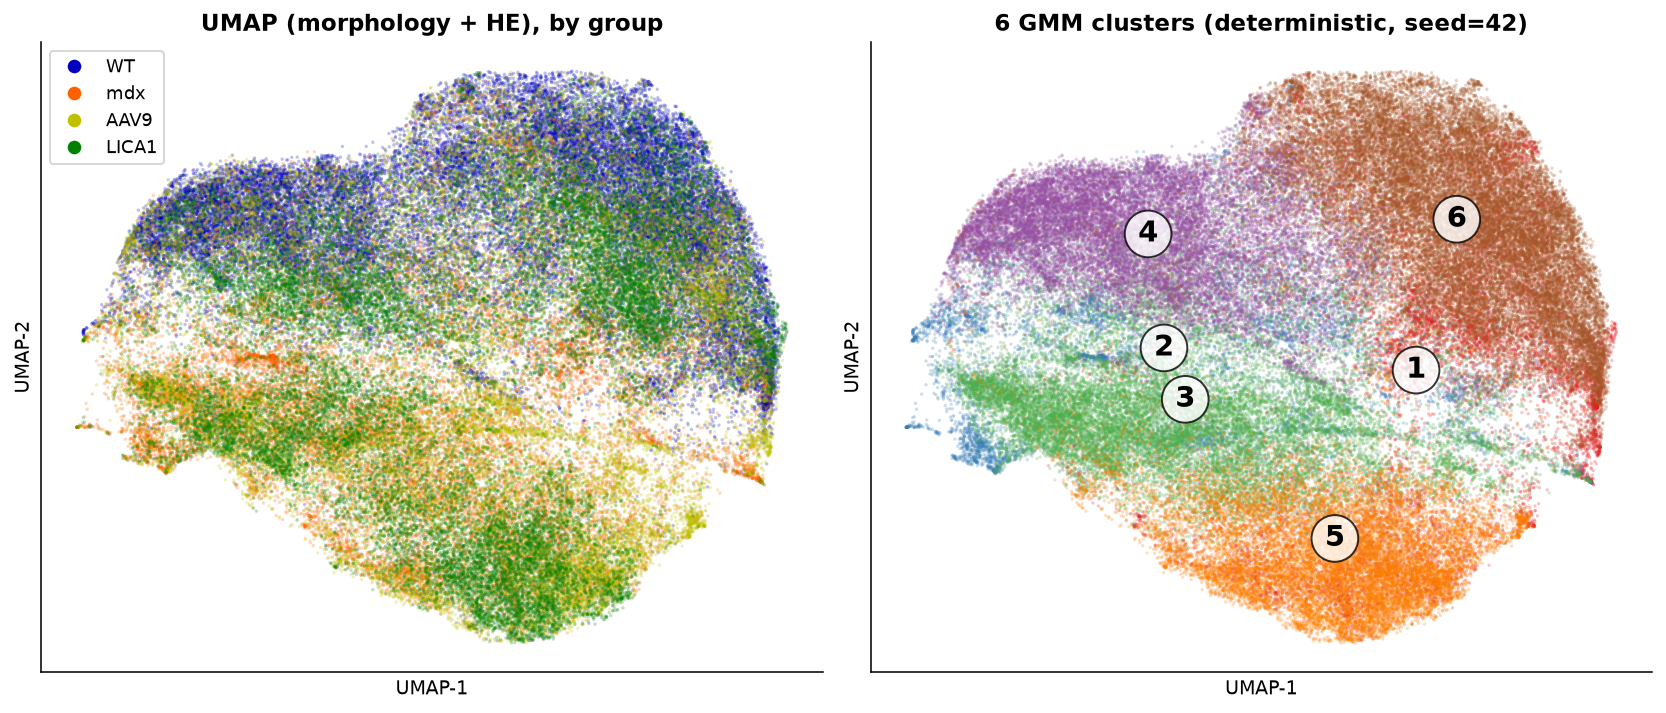

In [6]:
fig_umap_reference(q, "fig_q1_umap.png"); Image("fig_q1_umap.png")

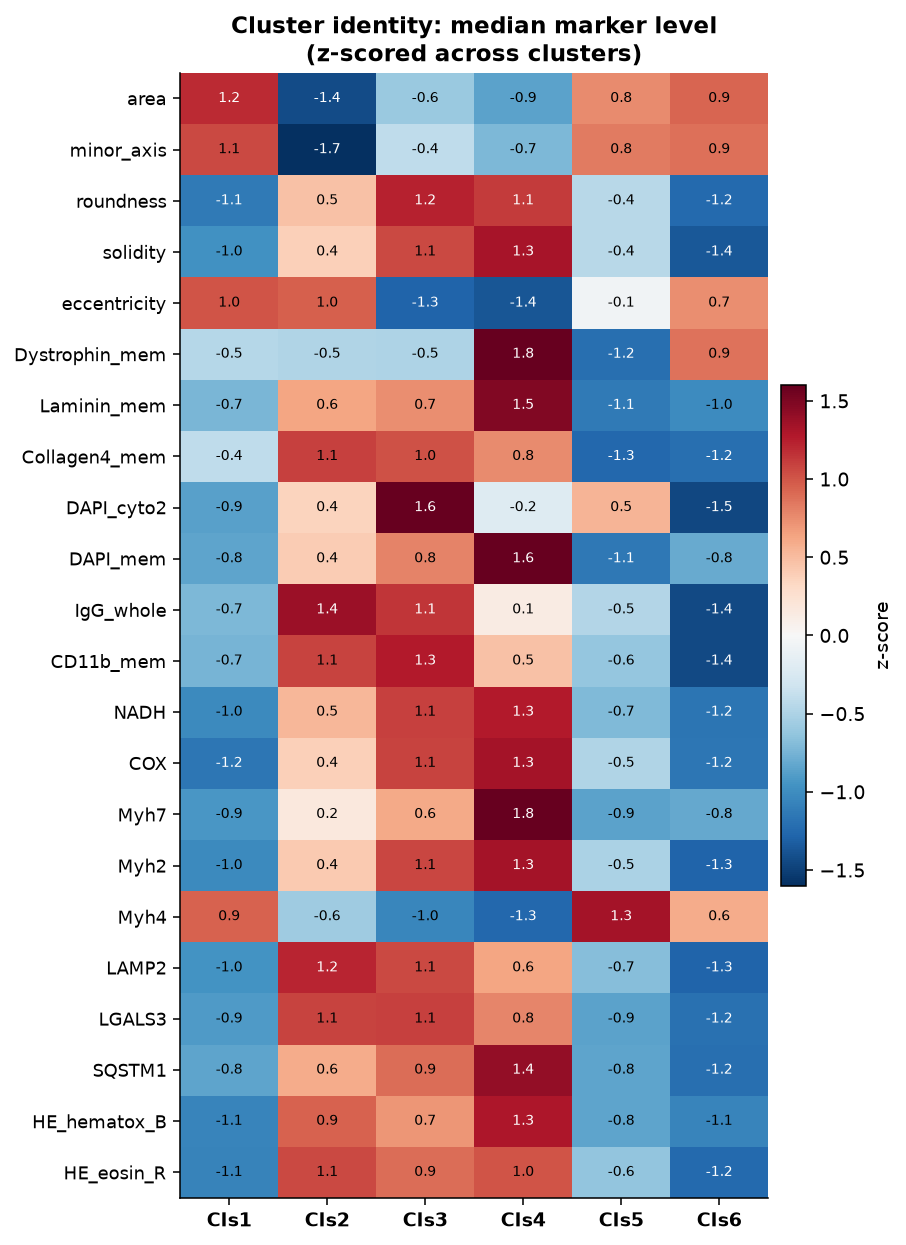

In [7]:
fig_cluster_identity(q, "fig_q1_identity.png"); Image("fig_q1_identity.png")

**Diễn giải định danh cluster (nền tảng cho cả 2 câu hỏi):**

| Cluster | Kiểu hình | Đặc điểm nổi bật |
|---|---|---|
| **Cls4** | **Khỏe – oxidative type I** | Dystrophin_mem **cao nhất**, Laminin cao, Myh7/Myh2 cao, NADH/COX cao, nhân ngoại vi (DAPI_mem) — *dominated bởi WT (62%)* |
| **Cls6** | **Khỏe – fast fiber lớn** | Fiber lớn, Dystrophin_mem cao (thứ 2), IgG **thấp nhất**, ít viêm — *WT (55%)* |
| **Cls3** | **Regenerating / viêm** | **DAPI_cyto2 cao nhất (central nucleation)**, oxidative cao, IgG/CD11b/LAMP2 cao — *mdx (38%)* |
| **Cls2** | **Necrotic-atrophic nhỏ** | Fiber **nhỏ nhất**, IgG **cao nhất**, CD11b/Collagen4/LAMP2 cao — *mdx (40%)* |
| **Cls5** | **Resistant – IIb lớn, dystrophin thấp** | Fiber lớn, **Myh4 cao nhất**, Dystrophin/Laminin **thấp nhất**, oxidative thấp — hầu như không có WT (1%) |
| **Cls1** | **Trung tính – IIb rất lớn, nhạt màu** | Fiber **lớn nhất**, mọi staining thấp, Myh4 cao — phân bố đều 4 nhóm (~25% mỗi nhóm) |

→ Hai cực khỏe (Cls4, Cls6) đối lập hai cực bệnh (Cls2 necrotic, Cls3 regenerating); Cls5 là quần thể
IIb lớn mất dystrophin; Cls1 là fiber IIb rất lớn nhạt màu, không đặc hiệu bệnh.

### 4 · Chữ ký toàn cục mdx vs WT
Effect size (Cohen's d, per-animal) cho từng marker; sao = mức ý nghĩa MWU.

        marker    m_g2    m_g1     d    p
Dystrophin_mem   49.76   30.58 -3.47 0.01
          Myh7   49.49   44.63 -0.84 0.31
   Laminin_mem   40.22   37.62 -0.49 0.55
           COX  181.57  179.11 -0.32 0.84
          Myh4   21.41   25.32  0.50 0.15
          area 5694.60 6309.00  1.09 0.15
    minor_axis   70.59   74.77  1.17 0.10
         LAMP2   36.50   45.59  1.20 0.11
          NADH   96.09  111.31  1.38 0.06
    DAPI_cyto2    2.98    3.30  2.06 0.06
      solidity    0.96    0.96  2.51 0.02
     roundness    0.74    0.75  2.56 0.02
     CD11b_mem   24.13   31.58  3.70 0.01
     IgG_whole   20.99   28.85  5.21 0.01


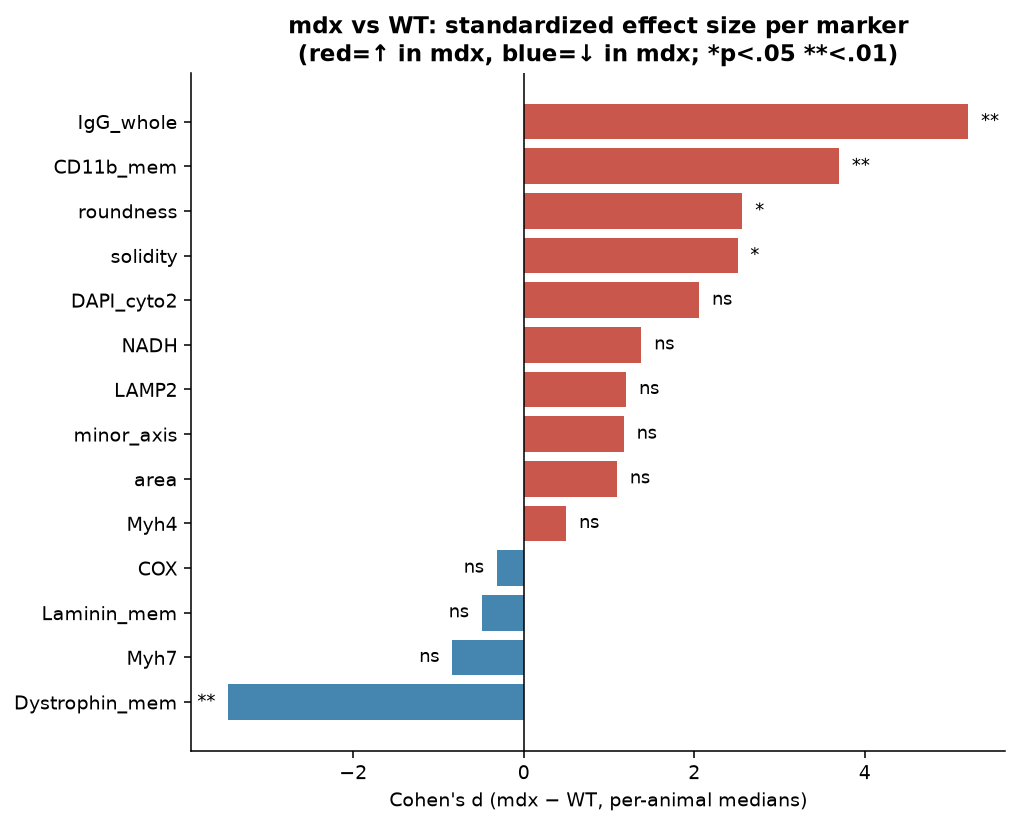

In [8]:
T = fig_global_effects(q, "fig_q1_effects.png")
import pandas as pd
print(T.round(2).to_string(index=False)); Image("fig_q1_effects.png")

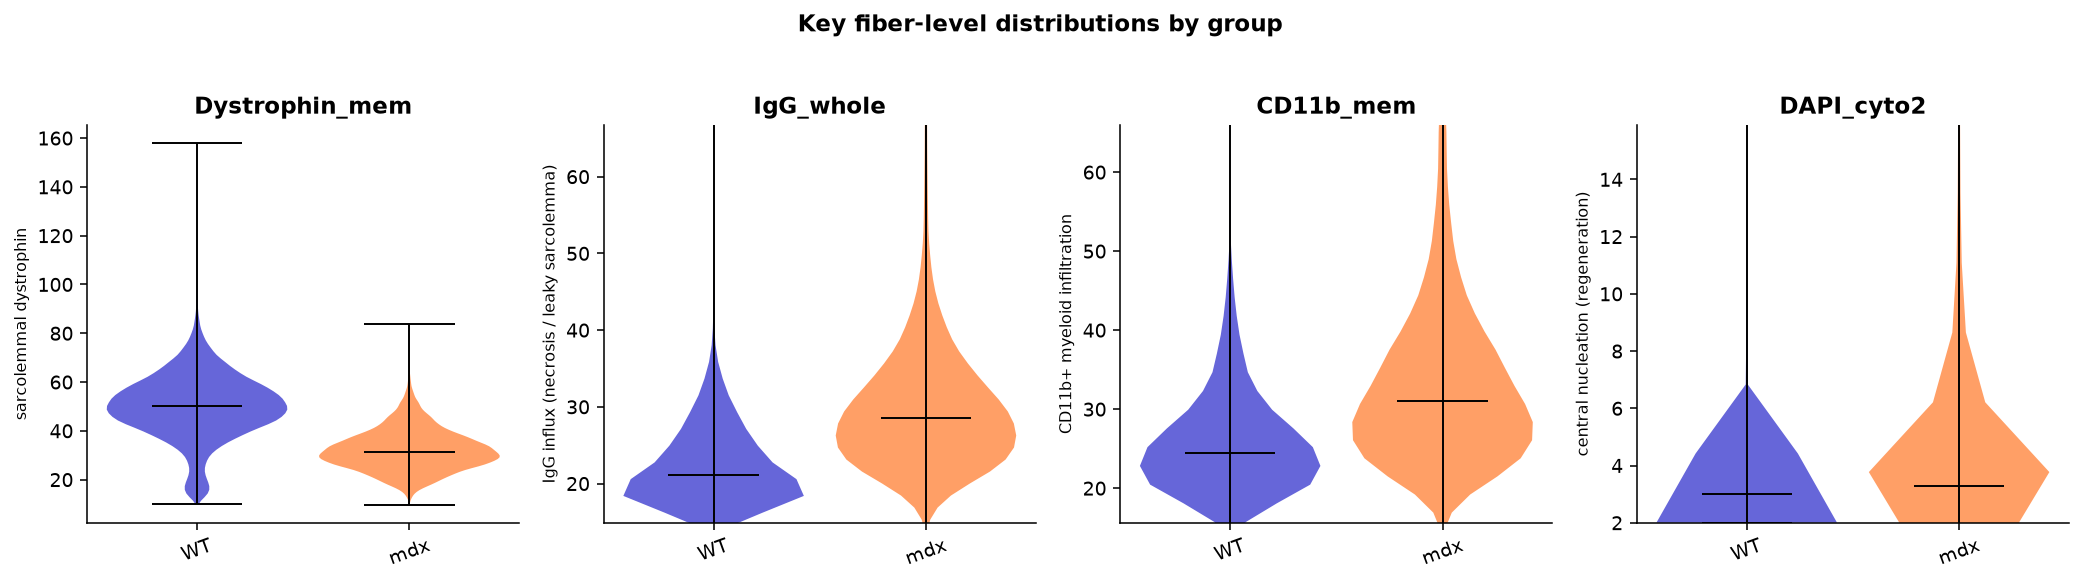

In [9]:
fig_key_violins(q, "fig_q1_violins.png", ["WT","mdx"]); Image("fig_q1_violins.png")

**Kết quả — chữ ký mdx kinh điển, tách hoàn toàn (p=0.008):**
- **Dystrophin_mem ↓↓ mạnh** (49.8 → 30.6; d ≈ **−3.5**): mất dystrophin ở sarcolemma — dấu ấn trung tâm của DMD.
- **IgG_whole ↑↑** (21 → 29; d ≈ **+5.2**): IgG tràn vào fiber = **màng rò rỉ / hoại tử** (necrosis).
- **CD11b_mem ↑↑** (24 → 32; d ≈ **+3.7**): thâm nhiễm đại thực bào (myeloid infiltration).
- **roundness/solidity ↑** (p=0.016) và **DAPI_cyto2 ↑** (central nucleation, regeneration) — fibers tròn hơn, nhân trung tâm nhiều hơn.
- **LAMP2/NADH ↑** nhẹ (lysosomal & metabolic stress). Myh7 (type I) giảm nhẹ (không có ý nghĩa).

### 5 · Tính không đồng nhất kích thước fiber (fiber-size heterogeneity)
Dấu hiệu mô học kinh điển của cơ dystrophic: fibers vừa teo vừa phì đại → tăng CV.

          CV  pct_small
group                  
WT     0.405      1.060
mdx    0.542      7.216
AAV9   0.489      4.548
LICA1  0.484      3.851


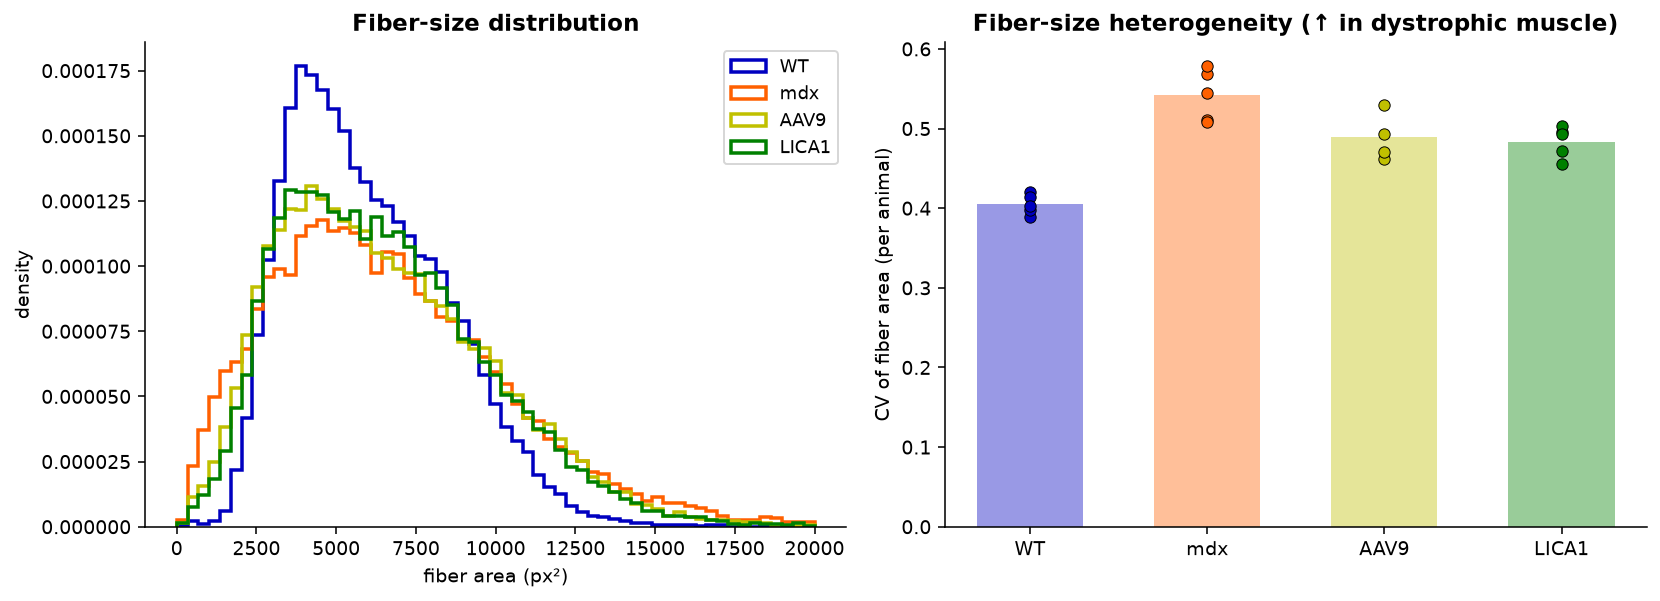

In [10]:
d = fig_size_heterogeneity(q, "fig_q1_hetero.png")
print(d.groupby("group")[["CV","pct_small"]].mean().reindex(GROUPS).round(3).to_string()); Image("fig_q1_hetero.png")

**Kết quả:** CV diện tích fiber tăng **0.40 (WT) → 0.54 (mdx)**; tỉ lệ fiber nhỏ (<2000 px²) tăng
1% → 7%, fiber lớn (>10000) tăng 7% → 19%. Phân bố kích thước dãn rộng hai đầu — đúng kiểu hình DMD.

### 6 · So sánh mdx vs WT **trong từng cluster**
Vì fibers trong một cluster đã *matched về hình thái* (clustering unbiased), so sánh WT–mdx trong cùng
cluster **tách riêng khác biệt phân tử khỏi khác biệt hình thái**. Ô = độ lệch median chuẩn hóa (mdx−WT).

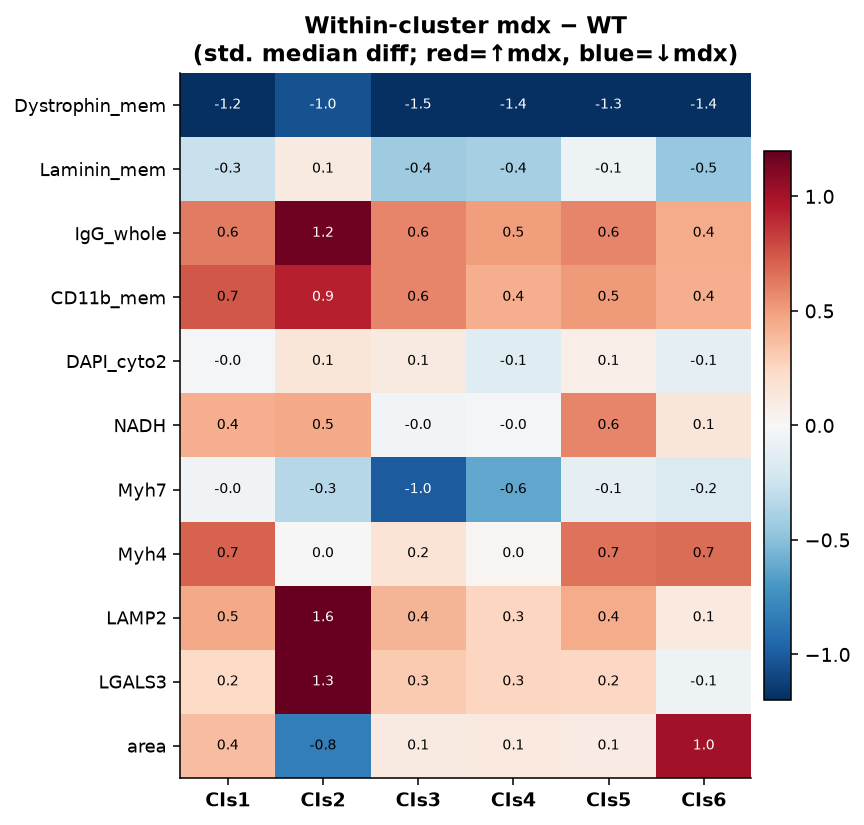

In [11]:
Dm = fig_within_cluster_delta(q, "fig_q1_wdelta.png"); Image("fig_q1_wdelta.png")

**Kết quả:** Dystrophin **giảm ở *mọi* cluster** (kể cả các cluster khỏe Cls4/Cls6) → mất dystrophin là
*fiber-intrinsic*, không phải chỉ do thay đổi thành phần cluster. IgG/CD11b tăng ở mọi cluster (viêm lan tỏa).
Ở Cls2/Cls3 (bệnh) mdx còn tăng DAPI_cyto2 (regeneration) và LAMP2/LGALS3 (lysosomal). Ở Cls6 mdx fiber
phì đại (area↑).

### 7 · **Cấu trúc tương quan bị mất** trong bệnh (correlation structure)
Không chỉ mức trung bình — *sự ghép cặp (coupling)* giữa các marker cũng thay đổi trong bệnh.

Dystrophin_mem~Laminin_mem      WT:+0.83 mdx:+0.91 AAV9:+0.76 LICA1:+0.73
NADH~Myh7             WT:+0.88 mdx:+0.67 AAV9:+0.78 LICA1:+0.76
IgG_whole~CD11b_mem        WT:+0.80 mdx:+0.73 AAV9:+0.66 LICA1:+0.80
Dystrophin_mem~NADH             WT:+0.19 mdx:+0.40 AAV9:+0.09 LICA1:+0.24


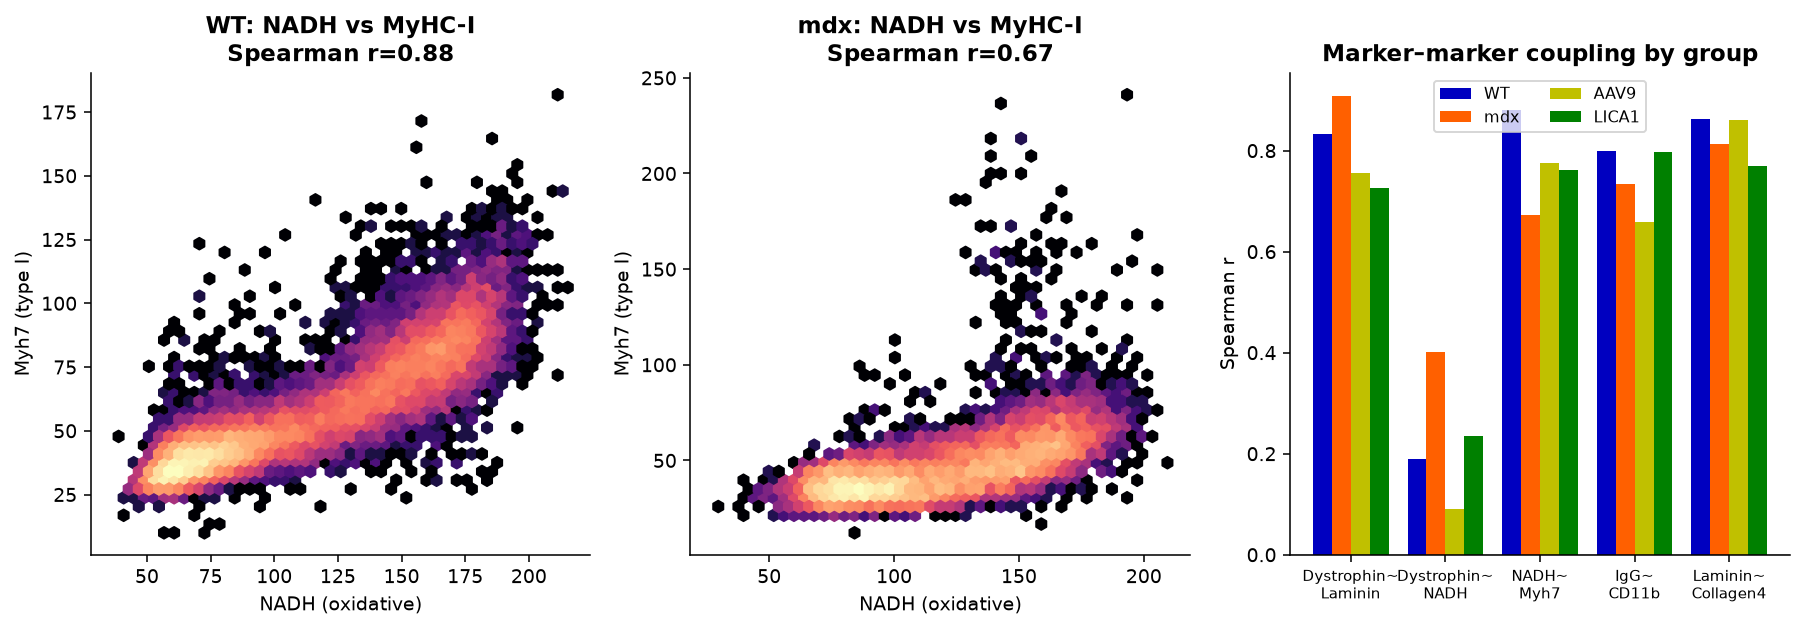

In [12]:
fig_correlation_structure(q, "fig_q1_corr.png")
for a,b in [("Dystrophin_mem","Laminin_mem"),("NADH","Myh7"),("IgG_whole","CD11b_mem"),("Dystrophin_mem","NADH")]:
    row=" ".join(f"{g}:{spearman_masked(q.mval(a)[q.groups==g], q.mval(b)[q.groups==g])[0]:+.2f}" for g in GROUPS)
    print(f"{a}~{b:16s} {row}")
Image("fig_q1_corr.png")

**Kết quả then chốt:**
- **NADH ~ Myh7 (metabolic ~ fiber-type coupling):** WT r=0.88 → **mdx r=0.67** — coupling chuyển hóa–loại sợi
  *lỏng ra* trong bệnh (metabolic dysregulation).
- **Dystrophin_mem ~ NADH:** WT 0.19 → **mdx 0.40** — ở mdx, dystrophin dư/residual tập trung ở fibers
  oxidative đang tái tạo (revertant/regenerating), nên coupling tăng.
- **Dystrophin ~ Laminin** vẫn cao ở mdx (0.83→0.91): laminin còn nguyên nên residual dystrophin vẫn bám màng.
- **IgG ~ CD11b** (necrosis ~ immune) vẫn ghép chặt (0.80→0.73): hoại tử kéo theo thâm nhiễm miễn dịch.

## Kết luận — Câu hỏi 1 (mdx vs WT)
1. **Mất dystrophin sarcolemmal** là khác biệt lớn nhất và *fiber-intrinsic* (mọi cluster; d≈−3.5, p=0.008).
2. **Màng rò rỉ + viêm:** IgG↑ (d≈+5.2) và CD11b↑ (d≈+3.7) — hoại tử và thâm nhiễm myeloid.
3. **Tái tạo:** central nucleation (DAPI_cyto2)↑, fibers tròn hơn; dịch chuyển thành phần sang các cluster
   bệnh Cls2 (necrotic nhỏ) và Cls3 (regenerating).
4. **Không đồng nhất kích thước** tăng mạnh (CV 0.40→0.54).
5. **Rối loạn chuyển hóa:** coupling NADH~type-I lỏng ra; lysosomal (LAMP2/LGALS3) tăng.

→ Bộ marker khách quan này tái hiện đầy đủ bệnh học DMD ở mức single-fiber, làm *baseline* để đánh giá
điều trị ở Notebook 2.